# Baseline Determination

Determination of both baseline components $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$ using five independent methods: FFT in the $x$-coordinate, phase slope, lag-spectrum delay, nonlinear least-squares fringe fitting, and brute-force grid search.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult, GridSearchResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    nls_baseline_single_channel, nls_baseline_broadband,
    grid_search_baseline,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    PRIMARY_COLOR, SECONDARY_COLOR, TERTIARY_COLOR, QUATERNARY_COLOR,
    NEUTRAL_COLOR, COMPONENT_COLORS,
    SCATTER_S_FINE, SCATTER_S_STANDARD,
    LW_FINE, LW_GUIDE, LW_STANDARD, LW_MODEL,
    MARKER_MS_SMALL,
    TEXTWIDTH_IN, TICK_SIZE,
)
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)            # per-capture declination
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 17–43 captures
  Chip 1: window range 17–27 captures
  Chip 2: window range 17–31 captures
Bad channels:       [0, 256, 512, 768]


# Part IV: Baseline Determination

We determine both baseline components $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$ using five independent methods, applied to all chips pooled.

## 4.1 Method 1: FFT in the x-coordinate

The visibility phase is $\phi = 2\pi(b_{\mathrm{ew}}/\lambda)\,x$ where $x = \cos\delta\,\sin h$. In this coordinate the fringe is a pure sinusoid with spatial frequency $f_x = b_{\mathrm{ew}}/\lambda$, so taking the FFT of the visibility in uniformly-sampled $x$ and finding the peak directly gives the baseline:

$$\boxed{b_{\mathrm{ew}} = |f_{x,\mathrm{peak}}| \times \frac{c}{\nu}.}$$

> **Limitation:** The $x$-coordinate linearisation absorbs the $\cos h$ term from $b_{\mathrm{ns}}$ — this method **only measures $b_{\mathrm{ew}}$** and returns $b_{\mathrm{ns}} = 0$ with infinite uncertainty. Methods 2–5 below recover both components.

In [4]:
# --- Method 1: FFT baseline (all chips pooled, broadband) ---
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)

fft_result, fft_per_ch = fft_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if fft_result is not None:
    print(f"FFT:  B_EW = {fft_result.b_ew_m:.4f} +/- {fft_result.b_ew_err_m:.4f} m  "
          f"({fft_result.n_points} channels, "
          f"median SNR = {fft_result.metadata.get('median_snr', 0):.1f})")

FFT:  B_EW = 15.5439 +/- 0.0026 m  (285 channels, median SNR = 117.1)


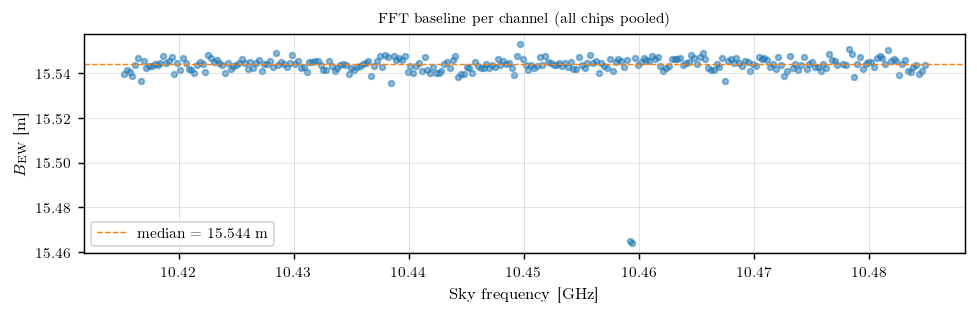

In [5]:
# --- FFT baseline: per-channel distribution ---
valid_ch = np.isfinite(fft_per_ch["b_ew_m"])

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.5))
ax.scatter(F_SKY_GHZ[valid_ch], fft_per_ch["b_ew_m"][valid_ch], s=SCATTER_S_FINE,
           color=PRIMARY_COLOR, alpha=0.5)
if fft_result is not None:
    ax.axhline(fft_result.b_ew_m, color=SECONDARY_COLOR, lw=LW_GUIDE,
               ls="--", label=f"median = {fft_result.b_ew_m:.3f} m")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel(r"$B_{\rm EW}$ [m]")
ax.set_title("FFT baseline per channel (all chips pooled)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

## 4.2 Method 2: Phase slope against physical regressors

The complex visibility has phase $\phi = \arg(V) = 2\pi\nu\tau'_g + \phi_c$, so the unwrapped phase is

$$\phi_i = \frac{2\pi\nu}{c}\bigl[b_{\mathrm{ew}}\cos\delta_i\,\sin h_i + b_{\mathrm{ns}}\sin L\,\cos\delta_i\,\cos h_i\bigr] + \phi_c.$$

The per-capture declination $\delta_i$ is folded directly into the design matrix
$$\mathbf{X} = \bigl[\cos\delta_i\sin h_i,\;\sin L\,\cos\delta_i\cos h_i,\;1\bigr],$$
so the fit coefficients $A$ and $B$ already absorb $\cos\delta$ and $\sin L$, giving

$$\boxed{b_{\mathrm{ew}} = \frac{A\,c}{2\pi\nu}, \qquad b_{\mathrm{ns}} = \frac{B\,c}{2\pi\nu}.}$$

> **Note:** Because $\cos\delta_i$ is a regressor column (not a divisor applied after fitting), no division by $\cos\delta$ is needed in the recovery. The sign of $b_{\mathrm{ew}}$ is degenerate with the cable phase, so only $|b_{\mathrm{ew}}|$ is reported; $b_{\mathrm{ns}}$ keeps its sign.

In [6]:
# --- Method 2: Phase slope (all chips pooled, broadband) ---
ps_result, ps_per_ch = phase_slope_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if ps_result is not None:
    ns = f"B_NS = {ps_result.b_ns_m:.4f} +/- {ps_result.b_ns_err_m:.4f} m" if np.isfinite(ps_result.b_ns_err_m) else "B_NS unconstrained"
    print(f"Phase slope:  B_EW = {ps_result.b_ew_m:.4f} +/- {ps_result.b_ew_err_m:.4f} m,  "
          f"{ns}  ({ps_result.n_points} channels)")

Phase slope:  B_EW = 14.4993 +/- 0.0102 m,  B_NS = -1.8125 +/- 0.0190 m  (285 channels)


## 4.3 Method 3: Lag-spectrum delay

The inverse FFT of the cross-correlation spectrum transforms frequency channels to a lag (delay) axis. The lag peak gives the geometric delay $\tau$ directly in nanoseconds. The fit uses the physical regressors (with per-capture declination) matching the delay model:

$$\tau_i = b_{\mathrm{ew}}\,\frac{\cos\delta_i\,\sin h_i}{c} + b_{\mathrm{ns}}\,\frac{\sin L\,\cos\delta_i\,\cos h_i}{c} + \tau_{\mathrm{inst}}$$

i.e. design matrix $[\cos\delta_i\sin h_i,\;\sin L\cos\delta_i\cos h_i,\;1]$ with the delay in nanoseconds, so coefficients $A$ (ns) and $B$ (ns) recover baselines directly as

$$b_{\mathrm{ew}} = A \cdot 10^{-9}\cdot c, \qquad b_{\mathrm{ns}} = B \cdot 10^{-9}\cdot c,$$

and the instrumental delay from the intercept $\tau_{\mathrm{inst}}$. This method is frequency-independent — all channels contribute to a single delay estimate per capture.

In [7]:
# --- Method 3: Lag-spectrum delay (all chips pooled) ---
lag_result = lag_delay_baseline_series(
    ha_rad_arr, corr_dc, dec_rad_arr, DF_HZ,
    bad_channels=BAD_CHANNELS,
)
if lag_result is not None:
    print(f"Lag delay:  B_EW = {lag_result.b_ew_m:.4f} +/- {lag_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {lag_result.b_ns_m:.4f} +/- {lag_result.b_ns_err_m:.4f} m  "
          f"(tau_inst = {lag_result.metadata['tau_inst_ns']:.2f} ns, "
          f"median SNR = {lag_result.metadata['median_snr']:.1f})")

Lag delay:  B_EW = 15.1334 +/- 0.0095 m,  B_NS = 1.5480 +/- 0.0293 m  (tau_inst = 47.10 ns, median SNR = 79.2)


## 4.4 Lag delay diagnostic: tau vs sin(h) and cos(h)

We visualise the lag delay as a function of $\sin h$ for the longest chip. The linear relationship validates the geometric-delay model, and the fit coefficients give both $b_{\mathrm{ew}}$ and $b_{\mathrm{ns}}$.

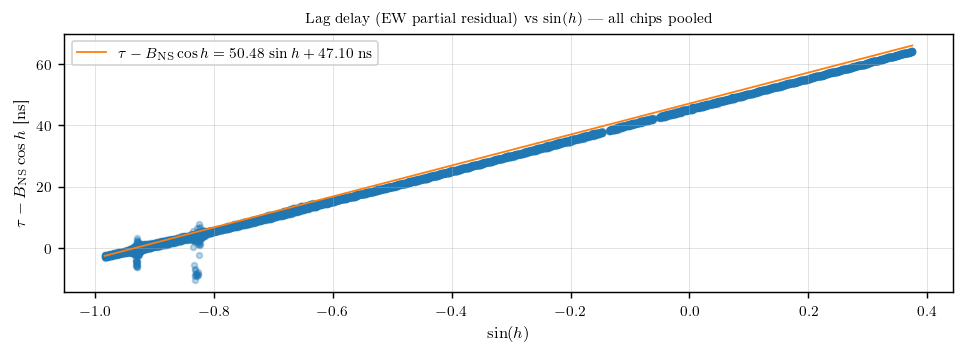

In [8]:
# --- Lag delay diagnostic plot (all chips pooled) ---
if lag_result is not None:
    sin_h = np.sin(ha_rad_arr)
    cos_h = np.cos(ha_rad_arr)
    tau_ns = lag_result.metadata["tau_ns"]
    valid = np.isfinite(tau_ns)

    A_ns = lag_result.metadata["A_ns_per_sinh"]
    B_ns = lag_result.metadata["B_ns_per_cosh"]
    intercept = lag_result.metadata["tau_inst_ns"]

    # Partial residual: subtract the cos(h) (NS) contribution so that the
    # scatter shows only the EW/sin(h) component.  The overlay then reduces
    # to a straight line A_ns * sin(h) + tau_inst, which can be compared
    # directly to the points.
    #   Full model: tau = A*sin(h) + B*cos(h) + tau_inst
    #   Subtract B*cos(h): tau - B*cos(h) = A*sin(h) + tau_inst
    tau_partial = tau_ns - B_ns * cos_h

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
    ax.scatter(sin_h[valid], tau_partial[valid], s=SCATTER_S_FINE, color=PRIMARY_COLOR, alpha=0.3)

    # Overlay: A_ns * sin(h) + tau_inst — an exact description of the plotted points
    x_fit = np.linspace(sin_h[valid].min(), sin_h[valid].max(), 100)
    ax.plot(x_fit, A_ns * x_fit + intercept, lw=LW_STANDARD, color=SECONDARY_COLOR,
            label=rf"$\tau - B_{{\rm NS}}\cos h = {A_ns:.2f}\,\sin h + {intercept:.2f}$ ns")

    ax.set_xlabel(r"$\sin(h)$")
    ax.set_ylabel(r"$\tau - B_{\rm NS}\cos h$ [ns]")
    ax.set_title("Lag delay (EW partial residual) vs $\\sin(h)$ — all chips pooled", fontsize=TICK_SIZE)
    ax.legend(fontsize=TICK_SIZE)
    fig.tight_layout()
    plt.show()

## 4.5 Method 4: Nonlinear least-squares complex fringe fit

This method fits the full fringe equation directly to the complex visibility:

$$V_i = (A + iC)\cos\psi_i + (B + iD)\sin\psi_i,$$
$$\psi_i = 2\pi\!\left[\frac{b_{\mathrm{ew}}}{\lambda}\cos\delta_i\,\sin h_i + \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta_i\,\cos h_i\right].$$

Per-capture declination $\delta_i$ enters $\psi_i$ at every step. The linear parameters $(A, B, C, D)$ are solved analytically at each step; the nonlinear parameters $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ are optimised via Levenberg-Marquardt, seeded from the phase-slope result.

In [9]:
# --- Method 4: NLS fringe fit (all chips pooled, broadband) ---
nls_result, nls_per_ch = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if nls_result is not None:
    print(f"NLS:  B_EW = {nls_result.b_ew_m:.4f} +/- {nls_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_result.b_ns_m:.4f} +/- {nls_result.b_ns_err_m:.4f} m  "
          f"({nls_result.n_points} channels)")

NLS:  B_EW = 14.5212 +/- 0.0992 m,  B_NS = -1.7459 +/- 0.3429 m  (285 channels)


## 4.6 Method 5: Brute-force grid search

The lab manual's brute-force technique evaluates the cost function on a 2-D grid over $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$, solving $(A, B, C, D)$ analytically at each grid point. Unlike gradient-based methods, this is guaranteed to find the **global** minimum within the search range and produces a $\chi^2$ map that reveals the structure of the cost surface — degeneracies, sidelobes, and confidence contours.

Grid search (ch 655, 10.450 GHz):
  Seeded from NLS: Q_ew = 506.2, Q_ns = -60.9
  B_EW = 15.1964 +/- 0.0000 m
  B_NS = 1.2909 +/- 0.0000 m
  S2_min = 191.0157,  chi2_nu = 0.011615,  dof = 16446
  Curvature matrix [alpha]:
    [[162.87015025 123.60413862]
 [123.60413862  37.42768718]]
  Covariance matrix (sigma^2 * [alpha]^-1):
    [[-4.73432712e-05  1.56350143e-04]
 [ 1.56350143e-04 -2.06018760e-04]]


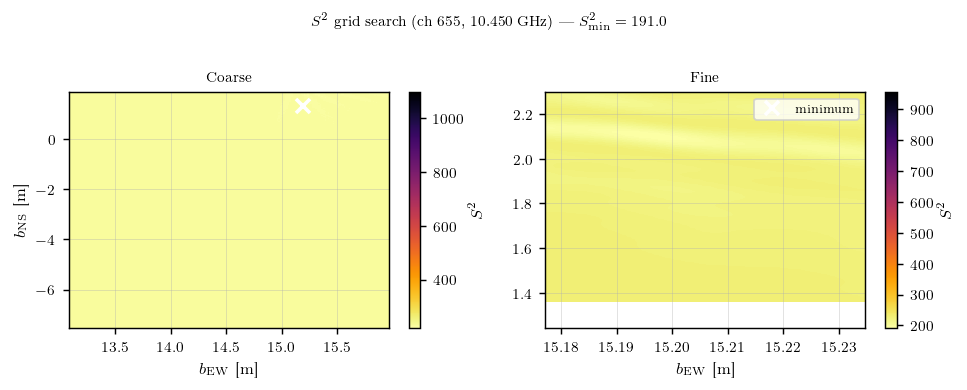

In [10]:
# --- Method 5: Brute-force grid search on a representative channel ---
# Seed the search range from the NLS fringe fit result
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
lam = C_LIGHT_MS / F_SKY_HZ[k_mid]

if nls_result is not None:
    q_ew_center = nls_result.b_ew_m / lam
    q_ns_center = nls_result.b_ns_m / lam
else:
    q_ew_center = NOMINAL_B_EW_M / lam
    q_ns_center = 0.0

gs = grid_search_baseline(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    n_coarse=200, n_fine=300,
    q_ew_range=(q_ew_center - 50.0, q_ew_center + 50.0),
    q_ns_range=(q_ns_center - 100.0, q_ns_center + 100.0),
)

if gs is not None:
    cos_dec = np.cos(dec_rad_mean)
    sin_lat = np.sin(np.deg2rad(NCH_LAT_DEG))
    dof = max(1, 2 * gs.n_points - 6)

    print(f"Grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz):")
    print(f"  Seeded from NLS: Q_ew = {q_ew_center:.1f}, Q_ns = {q_ns_center:.1f}")
    print(f"  B_EW = {gs.b_ew_m:.4f} +/- {gs.b_ew_err_m:.4f} m")
    print(f"  B_NS = {gs.b_ns_m:.4f} +/- {gs.b_ns_err_m:.4f} m")
    print(f"  S2_min = {gs.S2_min:.4f},  chi2_nu = {gs.S2_min / dof:.6f},  dof = {dof}")
    print(f"  Curvature matrix [alpha]:\n    {gs.alpha_matrix}")
    print(f"  Covariance matrix (sigma^2 * [alpha]^-1):\n    {gs.covariance_matrix}")

    # --- Side-by-side: coarse and fine S² maps ---
    fig, (ax_c, ax_f) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.38))

    # (a) Coarse grid
    b_ew_c = gs.Q_ew_coarse * lam / cos_dec
    b_ns_c = gs.Q_ns_coarse * lam / (sin_lat * cos_dec)
    S2_c_min = np.nanmin(gs.S2_coarse[np.isfinite(gs.S2_coarse)])

    im_c = ax_c.pcolormesh(
        b_ew_c, b_ns_c, gs.S2_coarse,
        cmap="inferno_r", shading="auto",
        vmin=S2_c_min, vmax=S2_c_min * 5,
    )
    ax_c.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2)
    ax_c.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_c.set_ylabel(r"$b_{\rm NS}$ [m]")
    ax_c.set_title("Coarse", fontsize=TICK_SIZE)
    fig.colorbar(im_c, ax=ax_c, label=r"$S^2$")

    # (b) Fine grid
    b_ew_f = gs.Q_ew_grid * lam / cos_dec
    b_ns_f = gs.Q_ns_grid * lam / (sin_lat * cos_dec)

    im_f = ax_f.pcolormesh(
        b_ew_f, b_ns_f, gs.S2_map,
        cmap="inferno_r", shading="auto",
        vmin=gs.S2_min, vmax=gs.S2_min * 5,
    )
    ax_f.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2, label="minimum")
    ax_f.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_f.set_title("Fine", fontsize=TICK_SIZE)
    ax_f.legend(fontsize=TICK_SIZE - 1)
    fig.colorbar(im_f, ax=ax_f, label=r"$S^2$")

    fig.suptitle(rf"$S^2$ grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz)"
                 rf" — $S^2_{{\min}} = {gs.S2_min:.1f}$",
                 fontsize=TICK_SIZE, y=1.02)
    fig.tight_layout()
    plt.show()

## 4.7 Baseline summary

In [11]:
# --- Baseline summary ---
def _fmt(val, fallback="---"):
    return f"{val:>12.4f}" if np.isfinite(val) else f"{fallback:>12}"

print("--- Baseline Summary ---")
print(f"{'Method':<20} {'B_EW [m]':>12} {'err':>8} {'B_NS [m]':>12} {'err':>8}")
print("-" * 63)
for label, res in [("FFT", fft_result),
                   ("Phase slope", ps_result),
                   ("Lag delay", lag_result),
                   ("NLS fringe fit", nls_result)]:
    if res is not None:
        print(f"  {label:<18} {_fmt(res.b_ew_m)} {_fmt(res.b_ew_err_m, 'inf'):>8} "
              f"{_fmt(res.b_ns_m)} {_fmt(res.b_ns_err_m, 'inf'):>8}")
if gs is not None:
    print(f"  {'Grid search':<18} {_fmt(gs.b_ew_m)} {_fmt(gs.b_ew_err_m):>8} "
          f"{_fmt(gs.b_ns_m)} {_fmt(gs.b_ns_err_m):>8}  (single ch)")

# Use NLS fringe fit as the adopted baseline — it fits the full complex
# fringe equation directly and recovers both baseline components from a
# broadband (multi-channel) fit with well-characterised uncertainties.
B_EW = nls_result.b_ew_m if nls_result is not None else lag_result.b_ew_m
B_NS = nls_result.b_ns_m if (nls_result is not None and np.isfinite(nls_result.b_ns_m)) else 0.0
B_EW_ERR = nls_result.b_ew_err_m if nls_result is not None else np.inf
B_NS_ERR = nls_result.b_ns_err_m if nls_result is not None else np.inf
R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)
print(f"\nAdopted: B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m,  "
      f"B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m  (NLS fringe fit)")

--- Baseline Summary ---
Method                   B_EW [m]      err     B_NS [m]      err
---------------------------------------------------------------
  FFT                     15.5439       0.0026       0.0000          inf
  Phase slope             14.4993       0.0102      -1.8125       0.0190
  Lag delay               15.1334       0.0095       1.5480       0.0293
  NLS fringe fit          14.5212       0.0992      -1.7459       0.3429
  Grid search             15.1964       0.0000       1.2909       0.0000  (single ch)

Adopted: B_EW = 14.5212 +/- 0.0992 m,  B_NS = -1.7459 +/- 0.3429 m  (NLS fringe fit)


# Part V: Fringe Model Comparison

With the baseline determined, we reconstruct the expected solar fringe pattern and overlay it on the observed data to validate the fit.

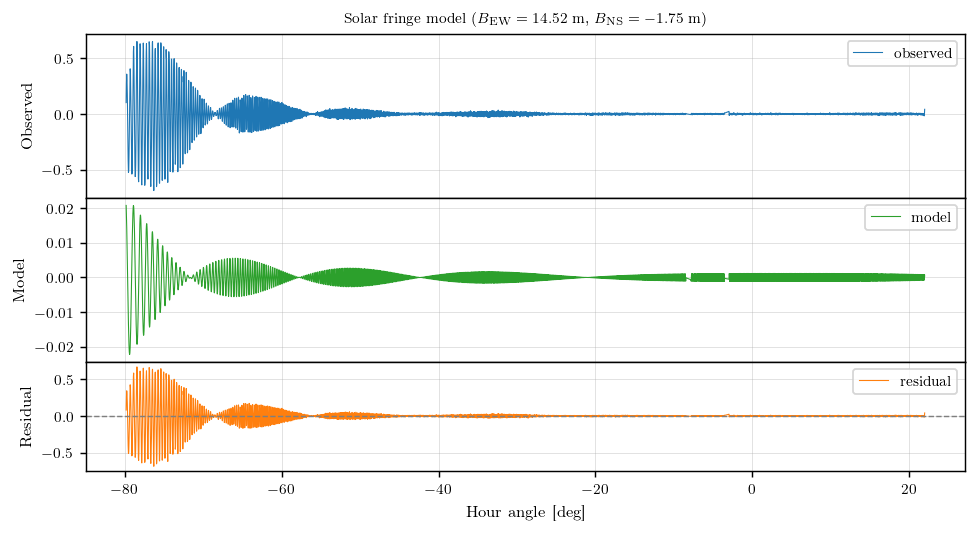

In [12]:
# --- Band-averaged observed fringes ---
corr_band = corr_dc[:, band_mask]
obs_real = np.nanmean(corr_band.real, axis=1)

# --- Solar fringe model with fitted baseline ---
params_fit = FringeModelParams(
    b_ew=B_EW,
    b_ns=B_NS,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)
disk_fit = SolarDiskParams(angular_radius_rad=R_nominal)
model_solar = solar_visibility(ha_rad_arr, params_fit, disk_fit)

# Fit amplitude and phase offset: V_obs ≈ a * V_model * exp(i*phi_0)
from scipy.optimize import minimize_scalar

def _phase_residual(phi0):
    rotated = model_solar * np.exp(1j * phi0)
    return np.nansum((obs_real - rotated.real) ** 2)

phi_opt = minimize_scalar(_phase_residual, bounds=(-np.pi, np.pi), method="bounded")
model_aligned = model_solar * np.exp(1j * phi_opt.x)
scale = np.nansum(obs_real * model_aligned.real) / np.nansum(model_aligned.real ** 2)
model_scaled = (scale * model_aligned).real
residual = obs_real - model_scaled

fig, axes = plot_fringe_model_comparison(
    ha_deg_arr, obs_real, model_scaled, residual,
    title=f"Solar fringe model ($B_{{\\rm EW}} = {B_EW:.2f}$ m, $B_{{\\rm NS}} = {B_NS:.2f}$ m)",
)
plt.show()

/tmp/ipykernel_167684/43715821.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


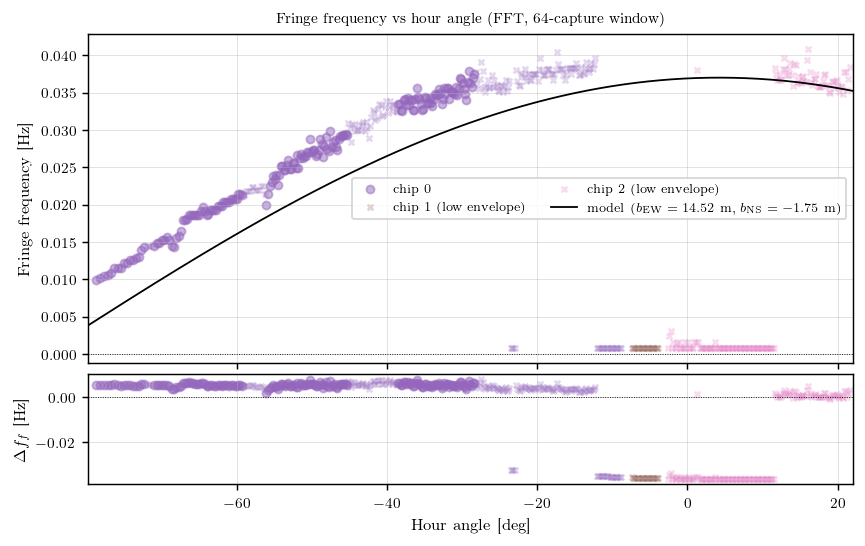

FFT window: 64 captures, step 16, zero-pad 8x
Total windows: 504  (high envelope: 175, low envelope: (~high_env).sum())
Residual RMS (high-envelope only): 0.0053 Hz
Low-envelope points (x markers) are near Bessel nulls where fringe amplitude < 5% of peak — FFT unreliable there


In [13]:
# --- Fringe frequency: model vs measured (sliding-window FFT) ---
# Model fringe frequency from the adopted (NLS) baseline
ff_model = fringe_frequency_hz(ha_rad_arr, dec_rad_mean, B_EW, B_NS, band_center_hz)

# Measured fringe frequency via sliding-window FFT of the band-averaged
# complex visibility time series.  Each window is Hann-tapered and
# zero-padded for sub-bin frequency resolution.
corr_band_avg = np.nanmean(corr_dc[:, band_mask], axis=1)

# Bessel envelope at each capture — used to flag low-SNR windows
env_at_caps = fringe_envelope(ha_rad_arr, params_fit, disk_fit)
env_peak = np.nanmax(env_at_caps)

WIN = 64            # window width [captures]
STEP = 16           # step between windows
PAD = 8             # zero-padding factor

ff_meas_list = []
ha_meas_list = []
chip_id_list = []
env_mean_list = []   # track mean envelope per window

for ci, chip_sl in enumerate(chip_slices):
    vis_chip = corr_band_avg[chip_sl]
    t_chip = unix_mid[chip_sl]
    ha_chip = ha_deg_arr[chip_sl]
    env_chip = env_at_caps[chip_sl]

    n_chip = len(vis_chip)
    if n_chip < WIN:
        continue

    for i0 in range(0, n_chip - WIN + 1, STEP):
        seg = vis_chip[i0 : i0 + WIN]
        t_seg = t_chip[i0 : i0 + WIN]
        env_seg = env_chip[i0 : i0 + WIN]

        # Skip if too many NaNs or non-uniform sampling
        good = np.isfinite(seg)
        if good.sum() < WIN * 0.8:
            continue
        dt_median = np.median(np.diff(t_seg))
        if dt_median <= 0:
            continue

        # Hann window, zero-pad, FFT
        seg_clean = np.where(good, seg, 0.0)
        seg_win = seg_clean * np.hanning(WIN)
        n_fft = WIN * PAD
        spectrum = np.fft.fft(seg_win, n=n_fft)
        freqs = np.fft.fftfreq(n_fft, d=dt_median)

        # Peak in positive-frequency half (skip DC)
        pos = (freqs > 0) & (freqs < 0.5 / dt_median)
        neg = (freqs < 0) & (freqs > -0.5 / dt_median)

        power = np.abs(spectrum) ** 2
        peak_pos = freqs[pos][np.argmax(power[pos])]
        peak_neg = freqs[neg][np.argmax(power[neg])]

        # Choose the half with the stronger peak
        if power[pos].max() >= power[neg].max():
            ff_peak = peak_pos
        else:
            ff_peak = peak_neg

        ha_mid = np.mean(ha_chip[i0 : i0 + WIN])
        ff_meas_list.append(ff_peak)
        ha_meas_list.append(ha_mid)
        chip_id_list.append(ci)
        env_mean_list.append(np.mean(env_seg))

ha_meas = np.array(ha_meas_list)
ff_meas = np.array(ff_meas_list)
chip_ids = np.array(chip_id_list)
env_means = np.array(env_mean_list)

# Match sign convention: assign sign from the model
ff_model_at_meas = fringe_frequency_hz(
    np.deg2rad(ha_meas), dec_rad_mean, B_EW, B_NS, band_center_hz,
)
ff_meas_signed = np.sign(ff_model_at_meas) * np.abs(ff_meas)

# Split into high-envelope (reliable) and low-envelope (unreliable) points
high_env = env_means > 0.05 * env_peak

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# (a) Fringe frequency comparison, coloured by chip
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[0].scatter(ha_meas[mask_hi], ff_meas_signed[mask_hi], s=SCATTER_S_STANDARD,
                        alpha=0.5, color=color, label=f"chip {ci}")
    if mask_lo.any():
        axes[0].scatter(ha_meas[mask_lo], ff_meas_signed[mask_lo], s=SCATTER_S_FINE,
                        alpha=0.25, color=color, marker="x",
                        label=f"chip {ci} (low envelope)" if not mask_hi.any() else None)
axes[0].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k",
             label=f"model ($b_{{\\rm EW}}={B_EW:.2f}$ m, $b_{{\\rm NS}}={B_NS:.2f}$ m)")
axes[0].set_ylabel("Fringe frequency [Hz]")
axes[0].set_title(f"Fringe frequency vs hour angle (FFT, {WIN}-capture window)",
                  fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2)
axes[0].axhline(0, color="k", lw=0.5, ls=":")

# (b) Residual
resid_ff = ff_meas_signed - ff_model_at_meas
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[1].scatter(ha_meas[mask_hi], resid_ff[mask_hi], s=SCATTER_S_STANDARD,
                        alpha=0.5, color=color)
    if mask_lo.any():
        axes[1].scatter(ha_meas[mask_lo], resid_ff[mask_lo], s=SCATTER_S_FINE,
                        alpha=0.25, color=color, marker="x")
axes[1].axhline(0, color="k", lw=0.5, ls=":")
axes[1].set_ylabel(r"$\Delta f_f$ [Hz]")
axes[1].set_xlabel("Hour angle [deg]")

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

rms_hi = np.sqrt(np.nanmean(resid_ff[high_env]**2)) if high_env.any() else np.nan
print(f"FFT window: {WIN} captures, step {STEP}, zero-pad {PAD}x")
print(f"Total windows: {len(ff_meas)}  "
      f"(high envelope: {high_env.sum()}, low envelope: (~high_env).sum())")
print(f"Residual RMS (high-envelope only): {rms_hi:.4f} Hz")
print(f"Low-envelope points (x markers) are near Bessel nulls where "
      f"fringe amplitude < 5% of peak — FFT unreliable there")

/tmp/ipykernel_167684/641090957.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


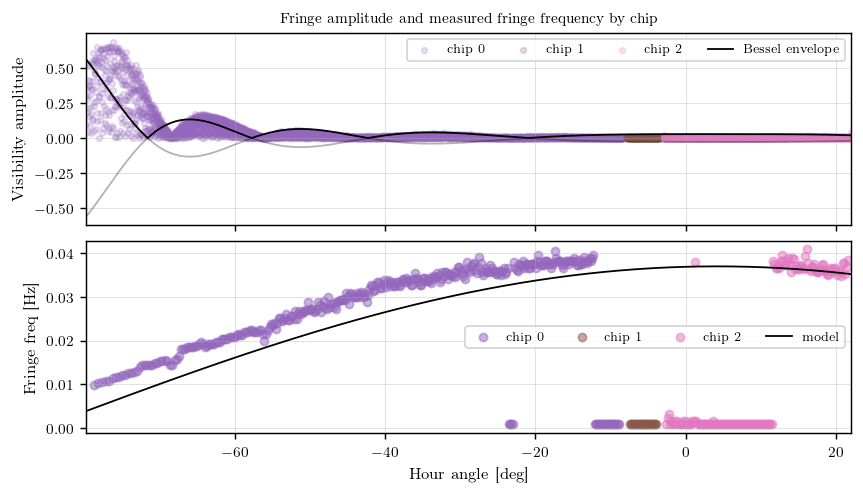

Chip 0: HA = -79.9 to -8.4 deg  (5514 captures)
Chip 1: HA = -7.8 to -3.5 deg  (403 captures)
Chip 2: HA = -2.9 to 22.0 deg  (2309 captures)


In [14]:
# --- Diagnose: fringe amplitude envelope vs HA with chip boundaries ---
# Check whether the low fringe-frequency points coincide with Bessel nulls
env_model = fringe_envelope(ha_rad_arr, params_fit, disk_fit)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

# (a) Bessel envelope vs HA, coloured by chip
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], np.abs(obs_real[sl]), s=SCATTER_S_FINE, alpha=0.2,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}", rasterized=True)
axes[0].plot(ha_deg_arr, env_model, lw=LW_STANDARD, color="k", label="Bessel envelope")
axes[0].plot(ha_deg_arr, -env_model, lw=LW_STANDARD, color="k", alpha=0.3)
axes[0].set_ylabel("Visibility amplitude")
axes[0].set_title("Fringe amplitude and measured fringe frequency by chip", fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=4)

# (b) FFT-measured fringe frequency, coloured by chip
# Re-derive chip assignment for each FFT window midpoint
for ci, sl in enumerate(chip_slices):
    ha_lo, ha_hi = ha_deg_arr[sl].min(), ha_deg_arr[sl].max()
    in_chip = (ha_meas >= ha_lo) & (ha_meas <= ha_hi)
    axes[1].scatter(ha_meas[in_chip], ff_meas_signed[in_chip],
                    s=SCATTER_S_STANDARD, alpha=0.5,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}")
axes[1].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k", label="model")
axes[1].set_ylabel("Fringe freq [Hz]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=4)

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

# Print chip HA ranges
for ci, sl in enumerate(chip_slices):
    print(f"Chip {ci}: HA = {ha_deg_arr[sl].min():.1f} to {ha_deg_arr[sl].max():.1f} deg  "
          f"({sl.stop - sl.start} captures)")